In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

In [3]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/train.csv',parse_dates=['datetime'])
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [5]:
train.temp.describe()

,temp
count,10886.00000
mean,20.23086
std,7.79159
min,0.82000
25%,13.94000
50%,20.50000
75%,26.24000
max,41.00000


In [6]:
train.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


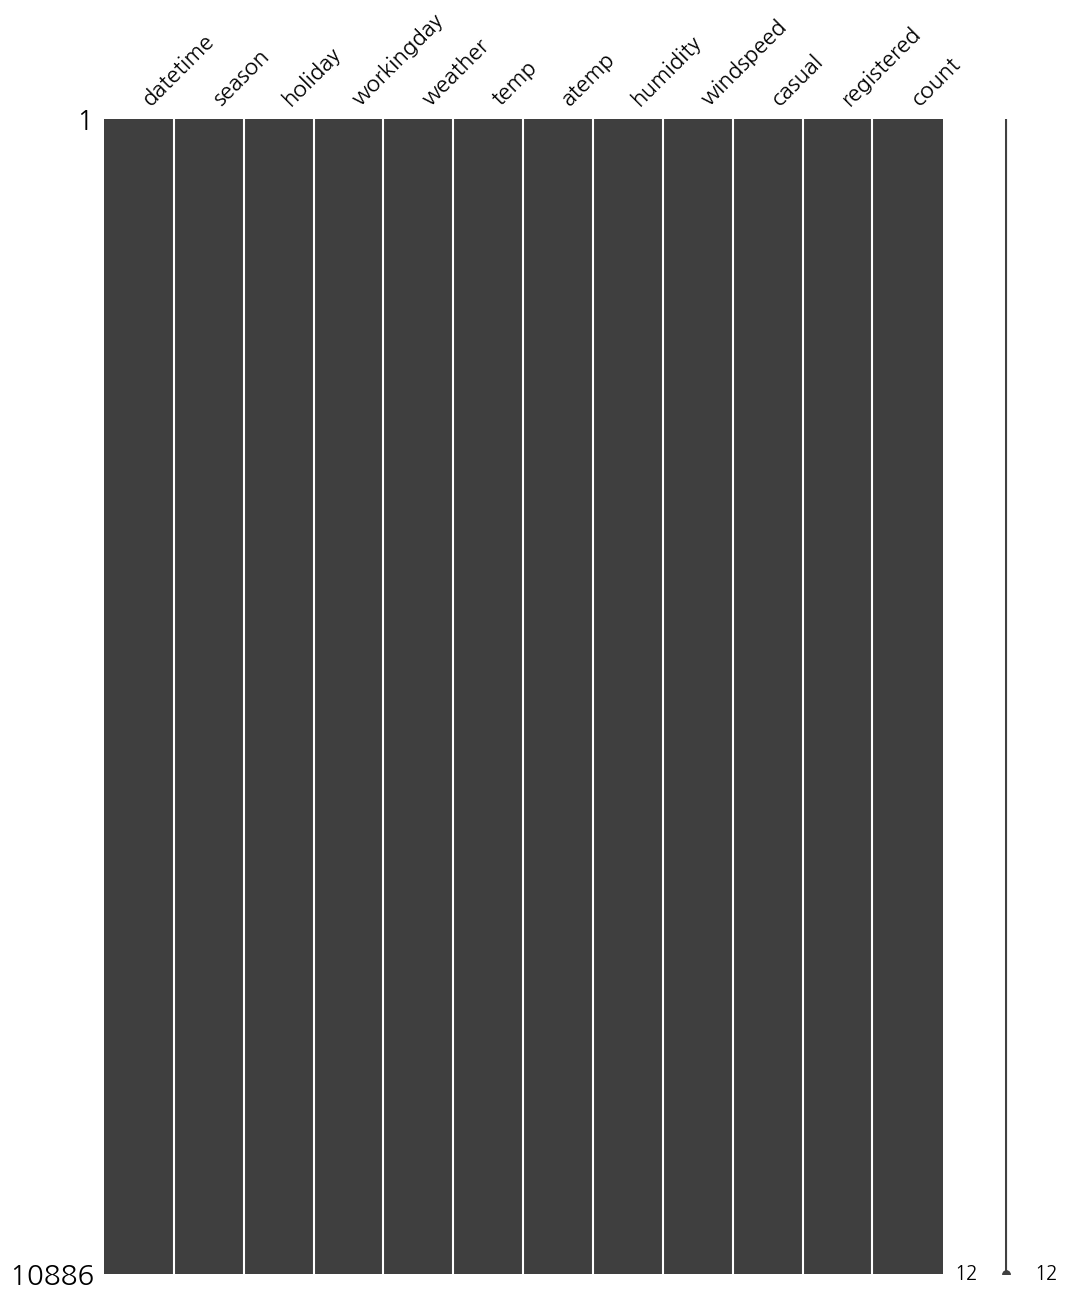

In [7]:
import missingno as msno

msno.matrix(train,figsize=(12,15))
plt.show()

In [8]:
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

In [9]:
train.shape

(10886, 18)

[Text(0.5, 0, 'hour'), Text(0.5, 1.0, '시간별 대여량')]

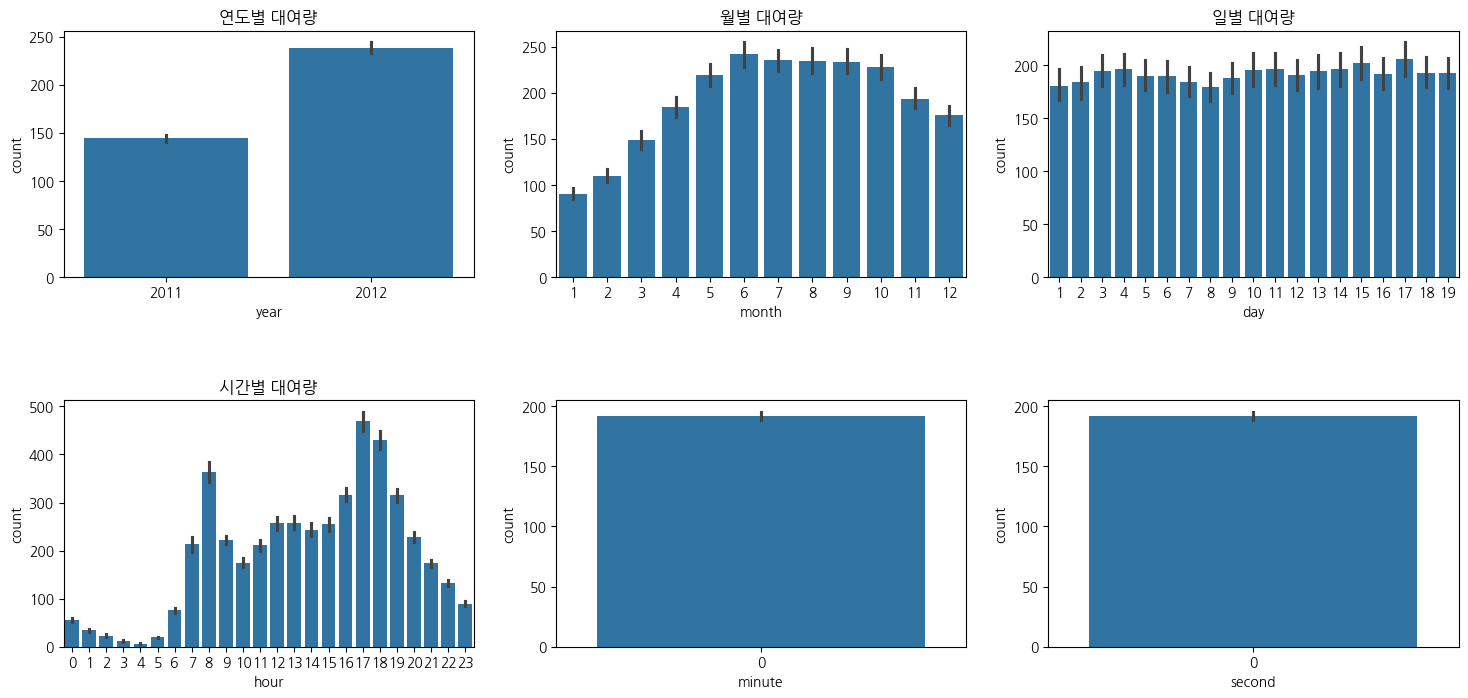

In [10]:
figure, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(nrows=2,ncols=3)
figure.set_size_inches(18,8)
figure.subplots_adjust(hspace=0.5)

sns.barplot(data=train,x='year',y='count',ax=ax1)
sns.barplot(data=train,x='month',y='count',ax=ax2)
sns.barplot(data=train,x='day',y='count',ax=ax3)
sns.barplot(data=train,x='hour',y='count',ax=ax4)
sns.barplot(data=train,x='minute',y='count',ax=ax5)
sns.barplot(data=train,x='second',y='count',ax=ax6)

ax1.set(ylabel='count',title='연도별 대여량')
ax2.set(xlabel='month',title='월별 대여량')
ax3.set(xlabel='day',title='일별 대여량')
ax4.set(xlabel='hour',title='시간별 대여량')

[Text(0.5, 0, 'workingday'),
 Text(0, 0.5, 'count'),
 Text(0.5, 1.0, '근무일 여부에 따른 대여량')]

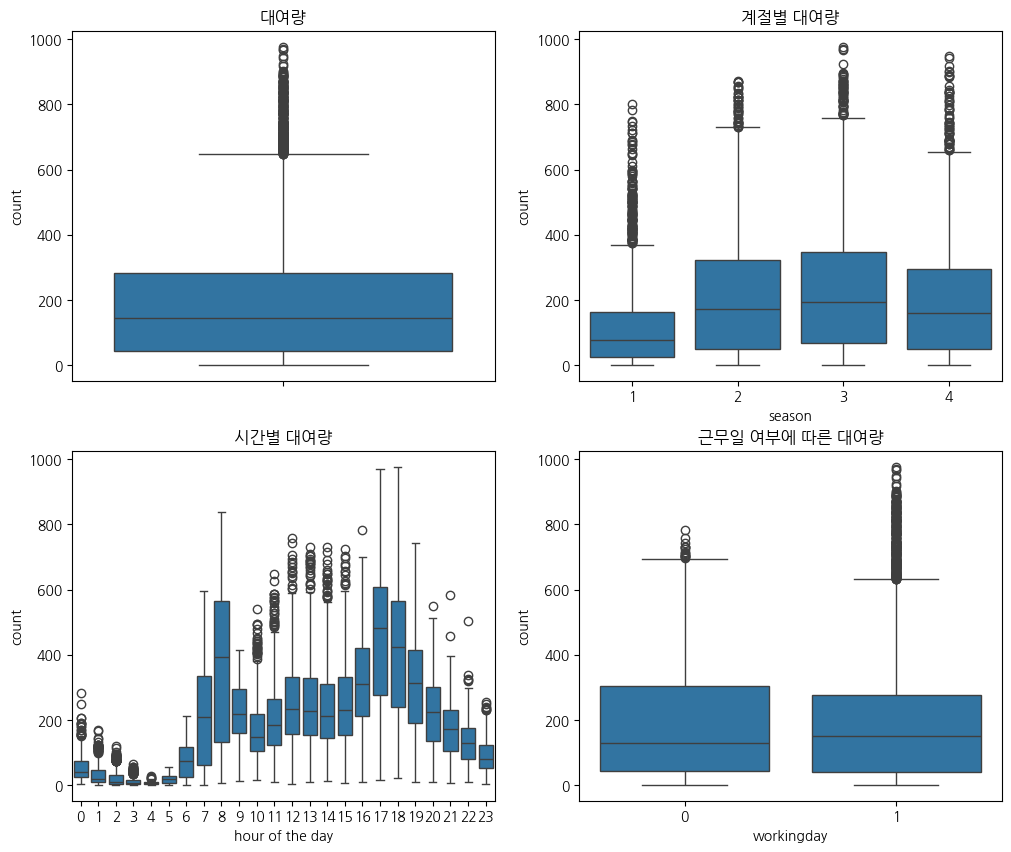

In [11]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(12,10)

sns.boxplot(data=train, y='count', orient='v', ax=axes[0][0])
sns.boxplot(data=train, y='count', x='season', orient='v', ax=axes[0][1])
sns.boxplot(data=train, y='count', x='hour', orient='v', ax=axes[1][0])
sns.boxplot(data=train, y='count', x='workingday', orient='v', ax=axes[1][1])

axes[0][0].set(ylabel='count',title='대여량')
axes[0][1].set(xlabel='season',ylabel='count',title='계절별 대여량')
axes[1][0].set(xlabel='hour of the day',ylabel='count',title='시간별 대여량')
axes[1][1].set(xlabel='workingday',ylabel='count',title='근무일 여부에 따른 대여량')


In [12]:
train['dayofweek'] = train['datetime'].dt.dayofweek
train.shape

(10886, 19)

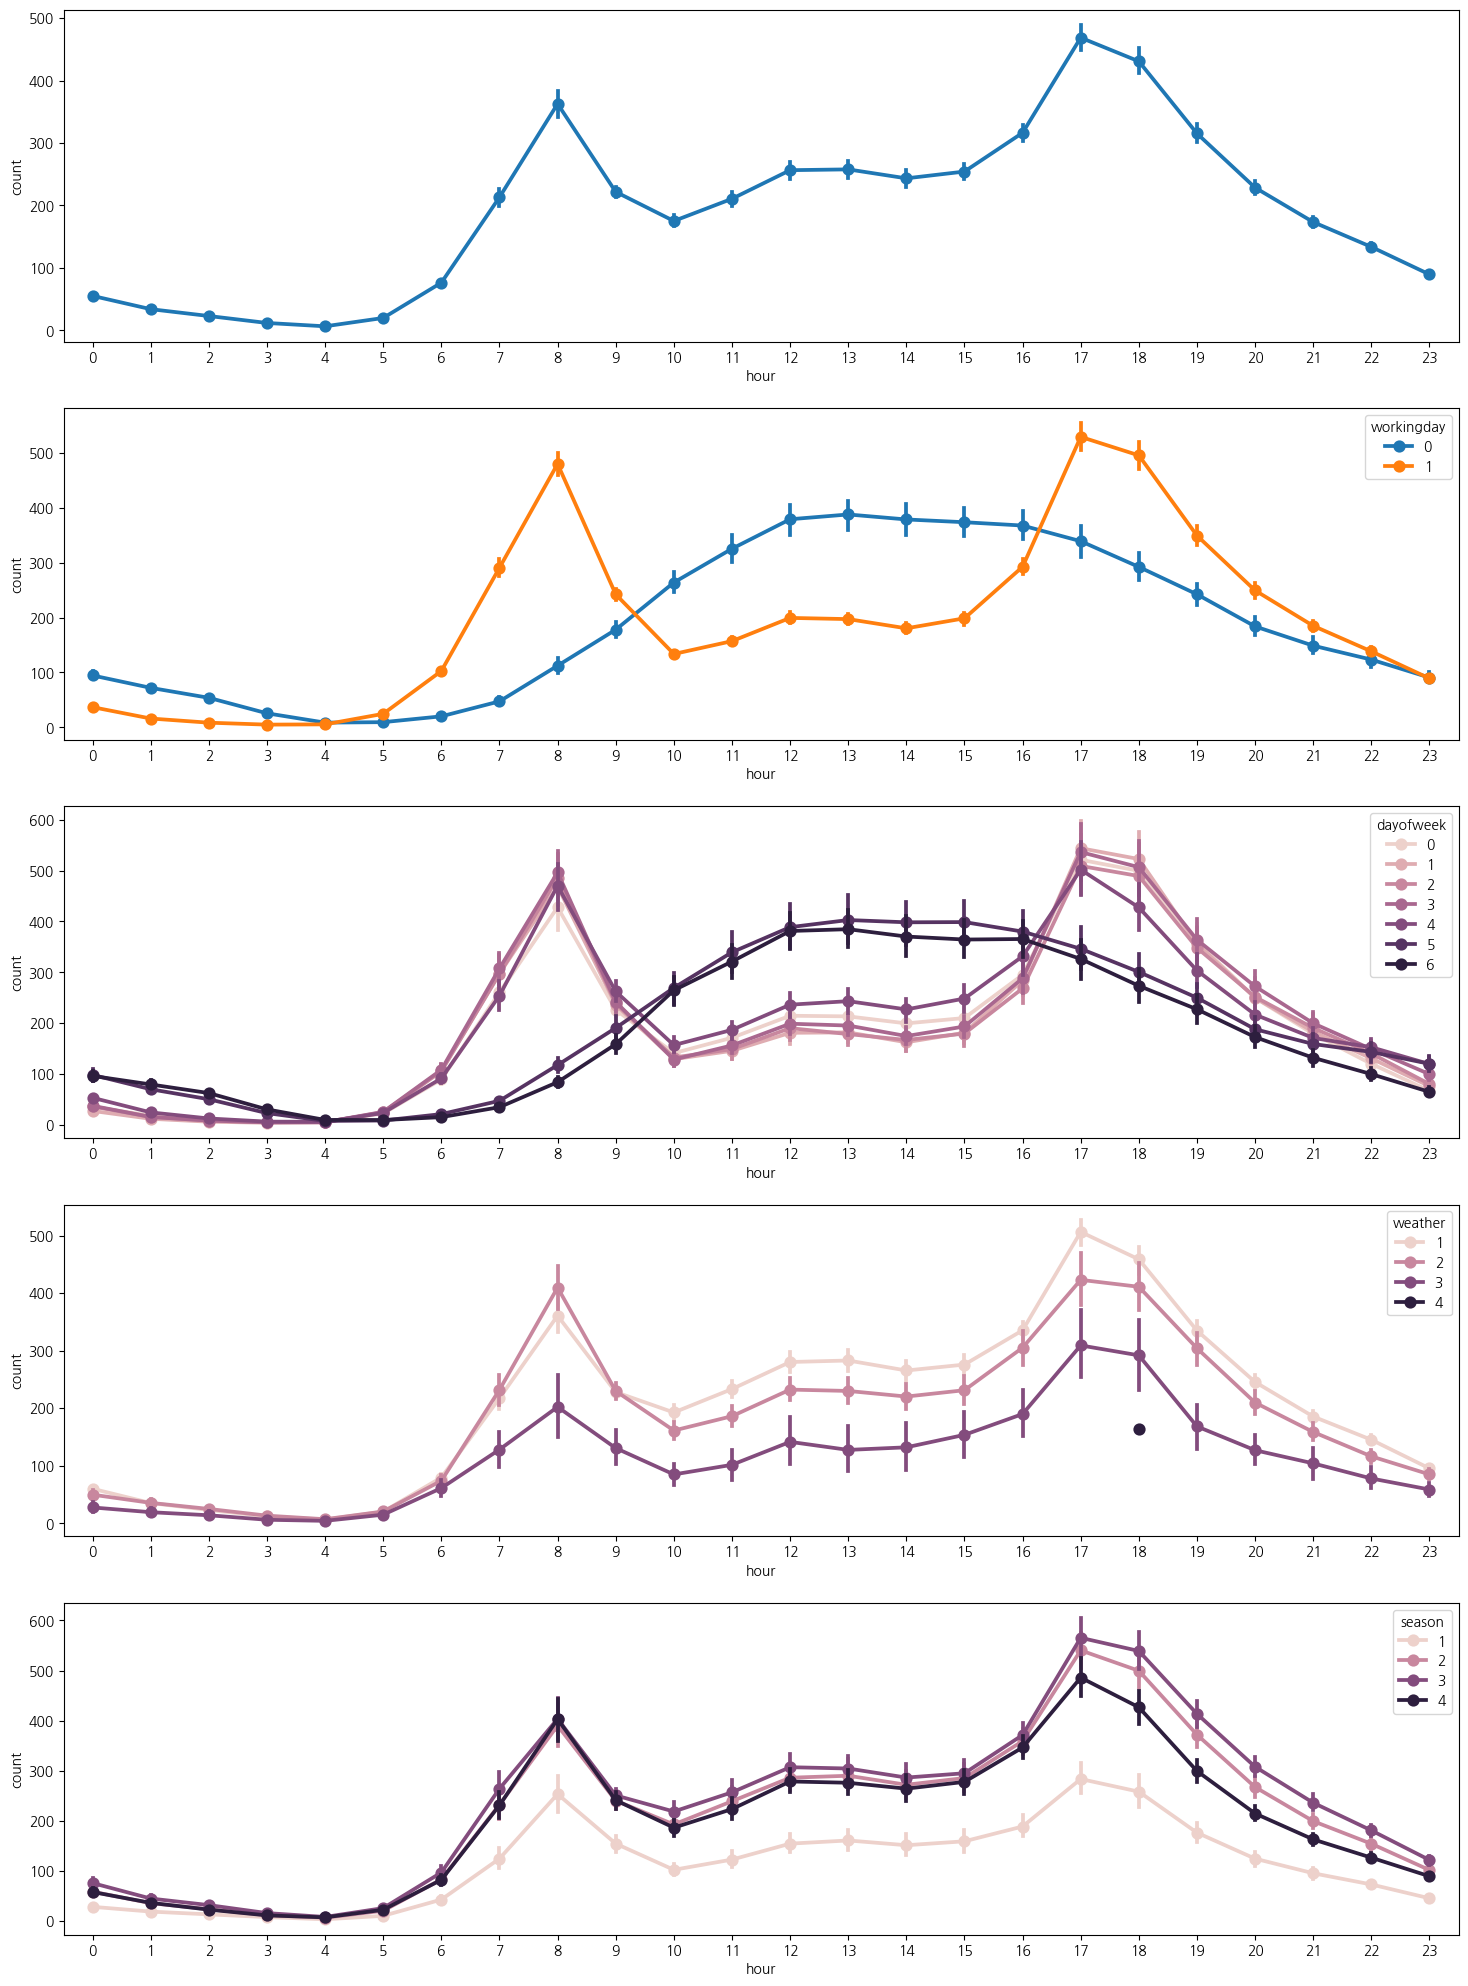

In [13]:
# 시간대별 대여량을 weekingday , datofweek , weather , season 에 따라서 비교

fig,(ax1,ax2,ax3,ax4,ax5) = plt.subplots(nrows=5)
fig.set_size_inches(18,25)

sns.pointplot(data=train,x='hour',y='count',ax=ax1)
sns.pointplot(data=train,x='hour',y='count',ax=ax2 , hue='workingday')
sns.pointplot(data=train,x='hour',y='count',ax=ax3 , hue='dayofweek')
sns.pointplot(data=train,x='hour',y='count',ax=ax4 , hue='weather')
sns.pointplot(data=train,x='hour',y='count',ax=ax5 , hue='season')
plt.show()

In [14]:
corrMatt = train[['temp','atemp','casual','registered','humidity','windspeed','count']]
corrMatt = corrMatt.corr()
print(corrMatt)

                temp     atemp    casual  registered  humidity  windspeed  \
temp        1.000000  0.984948  0.467097    0.318571 -0.064949  -0.017852   
atemp       0.984948  1.000000  0.462067    0.314635 -0.043536  -0.057473   
casual      0.467097  0.462067  1.000000    0.497250 -0.348187   0.092276   
registered  0.318571  0.314635  0.497250    1.000000 -0.265458   0.091052   
humidity   -0.064949 -0.043536 -0.348187   -0.265458  1.000000  -0.318607   
windspeed  -0.017852 -0.057473  0.092276    0.091052 -0.318607   1.000000   
count       0.394454  0.389784  0.690414    0.970948 -0.317371   0.101369   

               count  
temp        0.394454  
atemp       0.389784  
casual      0.690414  
registered  0.970948  
humidity   -0.317371  
windspeed   0.101369  
count       1.000000  


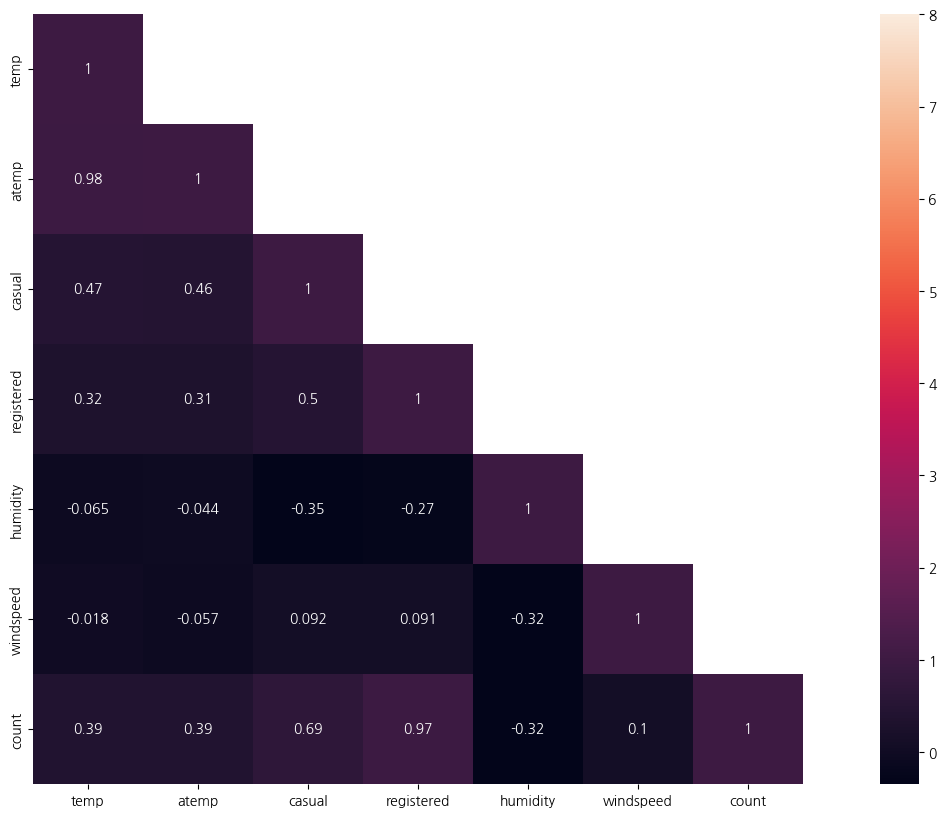

In [15]:
corrMatt = train[['temp','atemp','casual','registered','humidity','windspeed','count']]
corrMatt = corrMatt.corr()

mask = np.array(corrMatt)
mask[np.tril_indices_from(mask)] = False

fig,ax = plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(corrMatt,mask=mask,vmax=8,square=True,annot=True)
plt.show()

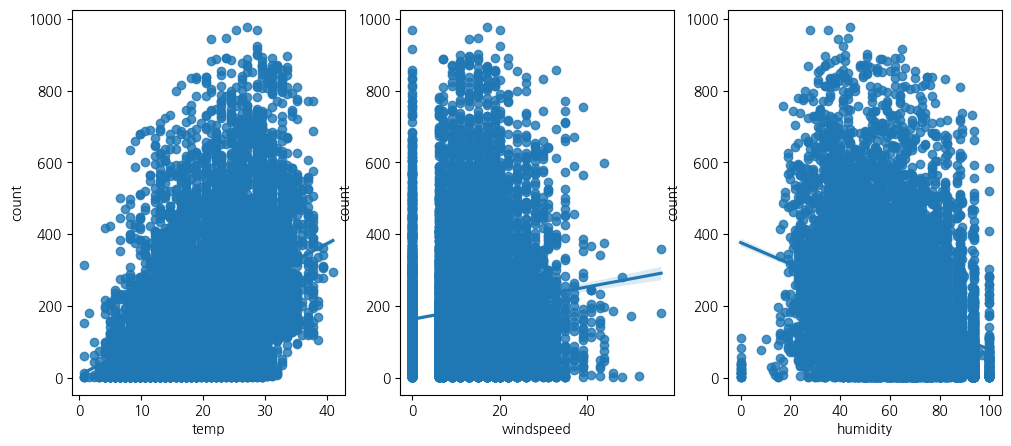

In [16]:
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3)
fig.set_size_inches(12,5)

sns.regplot(data=train,x='temp',y='count',ax=ax1)
sns.regplot(data=train,x='windspeed',y='count',ax=ax2)
sns.regplot(data=train,x='humidity',y='count',ax=ax3)
plt.show()

In [17]:
def con_year_month(datetime):
  return '{0}-{1}'.format(datetime.year,datetime.month)

train['year_month'] = train['datetime'].apply(con_year_month)

In [18]:
train[['datetime','year_month']].head()

,datetime,year_month
0,2011-01-01 00:00:00,2011-1
1,2011-01-01 01:00:00,2011-1
2,2011-01-01 02:00:00,2011-1
3,2011-01-01 03:00:00,2011-1
4,2011-01-01 04:00:00,2011-1


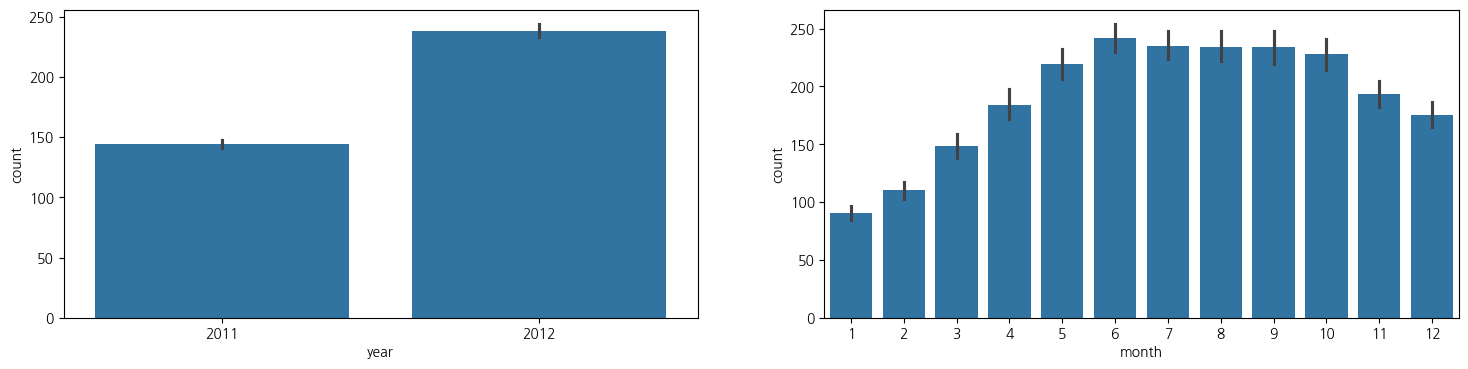

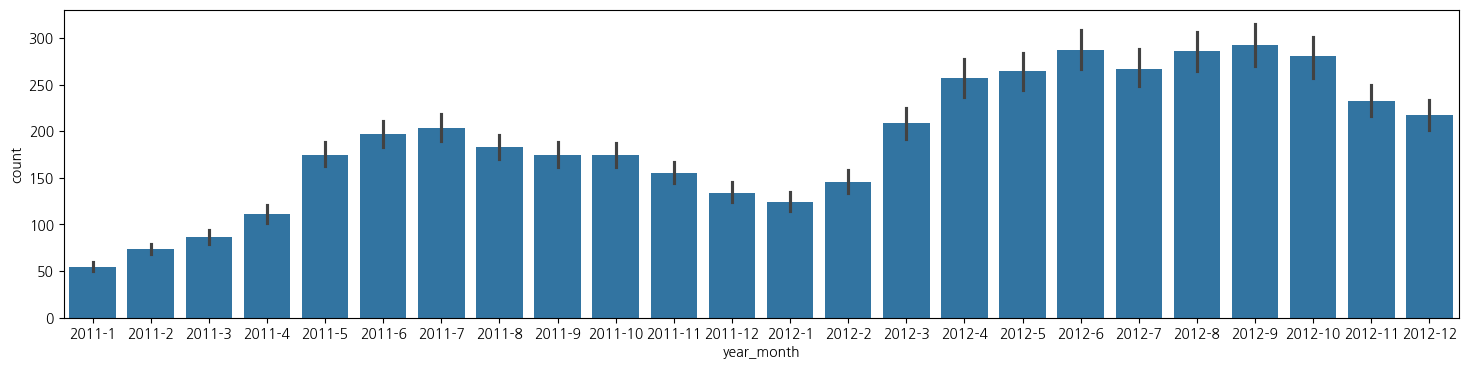

In [19]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(18,4)

sns.barplot(data=train, x='year', y='count', ax=ax1)
sns.barplot(data=train, x='month', y='count', ax=ax2)

fig, ax3 = plt.subplots(nrows=1)
fig.set_size_inches(18,4)
sns.barplot(data=train, x='year_month', y='count', ax=ax3)

plt.show()

In [20]:
outliers = train[np.abs(train['count']-train['count'].mean())<=(3*train['count'].std())]

In [21]:
outliers.shape

(10739, 20)

##수요량 예측(랜덤포레스트)

In [22]:
#풍속이 0인것과 0이 아닌것 세트를 나누어 준다
trainwind0=train.loc[train['windspeed']==0]
trainwindnot0=train.loc[train['windspeed']!=0]
trainwind0.shape

(1313, 20)

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
def predict_windspeed(data):
  trainwind0=train.loc[train['windspeed']==0]
  trainwindnot0=train.loc[train['windspeed']!=0]

  # 풍속을 예측한 특징 선택
  wcol = ['season','weather','humidity','month','temp','year','atemp']

  trainwindnot0['windspeed'] = trainwindnot0['windspeed'].astype('str')

  # 모델 선언
  model = RandomForestClassifier()

  # 풍속이 0이 아닌 데이터 학습
  model.fit(trainwindnot0[wcol],trainwindnot0['windspeed'])

  # 풍속이 0인 데이터의 풍속 예측
  windvlaues = model.predict(trainwind0[wcol])
  trainwind0['windspeed'] = windvlaues

  # 풍속이 0이 아닌 데이터와 예측된 데이터를 병합
  data = pd.concat([trainwindnot0,trainwind0],ignore_index=True)
  data['windspeed'] = data["windspeed"].astype('float')

  return data

In [34]:
train = predict_windspeed(train)

/tmp/ipython-input-1938965051.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainwindnot0['windspeed'] = trainwindnot0['windspeed'].astype('str')
/tmp/ipython-input-1938965051.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainwind0['windspeed'] = windvlaues
